In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

import lightgbm as lgb

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice, plot_contour

from time import time

import pickle

from src.config import *

/home/rstevenmartins/dmeyf_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_path = ''
dataset_path = 'data/'
modelos_path = 'modelos/'
db_path = 'optuna_studies/'
dataset_file = 'competencia_01.csv'

ganancia_acierto = 780000
costo_estimulo = 20000

mes_train = 202103
mes_test = 202104

# agregue sus semillas
semillas = 123479
SEMILLA = semillas
data = pd.read_csv('data/competencia_01.csv')

In [3]:
# First, let's identify numeric columns (exclude identifiers and target)
print("Identifying numeric columns...")

# Columns to exclude from lag creation
exclude_cols = ['numero_de_cliente', 'foto_mes', 'clase_ternaria', 'clase_binaria']

# Get numeric columns
numeric_cols = [
    col for col in data.columns
    if pd.api.types.is_numeric_dtype(data[col])
    and col not in exclude_cols
]

print(f"Number of numeric columns for lags: {len(numeric_cols)}")
print(f"First 10 numeric columns: {numeric_cols[:10]}")

Identifying numeric columns...
Number of numeric columns for lags: 152
First 10 numeric columns: ['active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen']


In [4]:
# CRITICAL: Sort by customer and month for proper lag calculation
print("\nSorting data by customer and month...")

# Ordenar usando pandas
data = data.sort_values(['numero_de_cliente', 'foto_mes'])

print("Data sorted successfully")
print(data[['numero_de_cliente', 'foto_mes', 'clase_ternaria']].head(10))


Sorting data by customer and month...
Data sorted successfully
   numero_de_cliente  foto_mes clase_ternaria
0          249221323    202101       CONTINUA
1          249221323    202102       CONTINUA
2          249221323    202103       CONTINUA
3          249221323    202104       CONTINUA
4          249221323    202105       CONTINUA
5          249221323    202106       CONTINUA
6          249227600    202101       CONTINUA
7          249227600    202102       CONTINUA
8          249227600    202103       CONTINUA
9          249227600    202104       CONTINUA


In [5]:
print("\nCreating lag features (batched)...")

# columnas clave (ajusta el nombre de la columna temporal si es distinto)
id_col   = "numero_de_cliente"
time_col = "foto_mes"          # si tu DF tiene otra columna temporal, cámbiala

# 1) ordenar por cliente y tiempo para que los lags tengan sentido
data = data.sort_values([id_col, time_col], kind="mergesort")

# 2) construir TODOS los lags con groupby().shift y guardarlos en un solo DataFrame
lags = {}
for col in numeric_cols:
    g = data.groupby(id_col)[col]
    lags[f"{col}_lag1"] = g.shift(1)
    lags[f"{col}_lag2"] = g.shift(2)

lag_df = pd.DataFrame(lags, index=data.index)

# 3) unir de una vez (evita fragmentación)
data = pd.concat([data, lag_df], axis=1)

print(f"Created {lag_df.shape[1]} lag features")
print(f"New shape: {data.shape}")



Creating lag features (batched)...
Created 304 lag features
New shape: (978439, 459)


In [6]:
print("\nCreating delta-lag features...")

# asumimos que ya existen las columnas *_lag1 y *_lag2
# y que numeric_cols contiene solo las columnas base (no las lag ni las delta)
delta_data = {}

for col in numeric_cols:
    # Delta 1: cambio respecto al mes anterior
    delta_data[f"{col}_delta1"] = data[col] - data[f"{col}_lag1"]

    # Delta 2: cambio entre los dos meses anteriores
    delta_data[f"{col}_delta2"] = data[f"{col}_lag1"] - data[f"{col}_lag2"]

# convertimos todo a un DataFrame y unimos de una vez
delta_df = pd.DataFrame(delta_data, index=data.index)
data = pd.concat([data, delta_df], axis=1)

print(f"Created {delta_df.shape[1]} delta-lag features")
print(f"Final shape: {data.shape}")


Creating delta-lag features...
Created 304 delta-lag features
Final shape: (978439, 763)


In [7]:
# # load data from data pickle
# with open(f'{base_path}{dataset_path}data_lags.pkl', 'rb') as f:
#     data = pickle.load(f)

In [7]:
data['clase_peso'] = 1.0

data.loc[data['clase_ternaria'] == 'BAJA+2', 'clase_peso'] = 1.00002
data.loc[data['clase_ternaria'] == 'BAJA+1', 'clase_peso'] = 1.00001

In [8]:
data['clase_binaria1'] = 0
data['clase_binaria2'] = 0
data['clase_binaria1'] = np.where(data['clase_ternaria'] == 'BAJA+2', 1, 0)
data['clase_binaria2'] = np.where(data['clase_ternaria'] == 'CONTINUA', 0, 1)

# seguimos

In [11]:
train_data = data[data['foto_mes'] == mes_train]
test_data = data[data['foto_mes'] == mes_test]

X_train = train_data.drop(['clase_ternaria', 'clase_peso', 'clase_binaria1','clase_binaria2', 'foto_mes', 'numero_de_cliente'], axis=1)
y_train_binaria1 = train_data['clase_binaria1']
y_train_binaria2 = train_data['clase_binaria2']
w_train = train_data['clase_peso']

X_test = test_data.drop(['clase_ternaria', 'clase_peso', 'clase_binaria1','clase_binaria2', 'foto_mes', 'numero_de_cliente'], axis=1)
y_test_binaria1 = test_data['clase_binaria1']
y_test_class = test_data['clase_ternaria']
w_test = test_data['clase_peso']

In [12]:
def lgb_gan_eval(y_pred, data):
    weight = data.get_weight()
    ganancia = np.where(weight == 1.00002, ganancia_acierto, 0) - np.where(weight < 1.00002, costo_estimulo, 0)
    ganancia = ganancia[np.argsort(y_pred)[::-1]]
    ganancia = np.cumsum(ganancia)

    return 'gan_eval', np.max(ganancia) , True

# Parámetros del modelos.
params = {
    'objective': 'binary',
    'metric': 'gan_eval',
    'boosting_type': 'gbdt',
    'max_bin': 31,
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.3,
    'bagging_fraction': 0.7,
    'verbose': 0
}

In [13]:
train_data1 = lgb.Dataset(X_train, label=y_train_binaria1, weight=w_train)
train_data2 = lgb.Dataset(X_train, label=y_train_binaria2, weight=w_train)

In [13]:
# cv_results1 = lgb.cv(
#     params,
#     train_data1,
#     num_boost_round=150,
#     feval=lgb_gan_eval,
#     nfold=5,
#     seed=SEMILLA
# )

# cv_results2 = lgb.cv(
#     params,
#     train_data2,
#     num_boost_round=150,
#     feval=lgb_gan_eval,
#     nfold=5,
#     seed=SEMILLA
# )

In [14]:
# df_ganancias = pd.DataFrame({
#     'binaria1': cv_results1['valid gan_eval-mean'],
#     'binaria2': cv_results2['valid gan_eval-mean'],
#     'Iteracion': range(1, len(cv_results1['valid gan_eval-mean']) + 1)
# })

# # Normalizamos la ganancias
# df_ganancias['binaria1'] = df_ganancias['binaria1']*5
# df_ganancias['binaria2'] = df_ganancias['binaria2']*5

# plt.figure(figsize=(10, 6))
# sns.lineplot(x='Iteracion', y='binaria1', data=df_ganancias, label='binaria 1')
# sns.lineplot(x='Iteracion', y='binaria2', data=df_ganancias, label='binaria 2')
# plt.title('Comparación de las Ganancias de las 2 clases binarias')
# plt.xlabel('Iteración')
# plt.ylabel('Ganancia')
# plt.legend()
# plt.show()


In [14]:
def objective(trial):

    num_leaves = trial.suggest_int('num_leaves', 8, 100),
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.3), # mas bajo, más iteraciones necesita
    min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 3, 50),
    feature_fraction = trial.suggest_float('feature_fraction', 0.1, 1.0),
    bagging_fraction = trial.suggest_float('bagging_fraction', 0.1, 1.0),
    min_gain_to_split = trial.suggest_float('min_gain_to_split', 0.0, 5.0),
    #max_depth = trial.suggest_int('max_depth', 3, 20)

    params = {
        'objective': 'binary',
        'metric': 'custom',
        'boosting_type': 'gbdt',
        'first_metric_only': True,
        'boost_from_average': True,
        'feature_pre_filter': False,
        'max_bin': 31,
        'num_leaves': num_leaves,
        'learning_rate': learning_rate,
        'min_data_in_leaf': min_data_in_leaf,
        'feature_fraction': feature_fraction,
        'bagging_fraction': bagging_fraction,
        'min_gain_to_split': min_gain_to_split,
        #'max_depth': max_depth,
        'seed': semillas,
        'verbose': -1
    }
    train_data = lgb.Dataset(X_train,
                              label=y_train_binaria2, # eligir la clase
                              weight=w_train)
    cv_results = lgb.cv(
        params,
        train_data,
        num_boost_round=500, # modificar, subit y subir... y descomentar la línea inferior
        # early_stopping_rounds= int(50 + 5 / learning_rate),
        feval=lgb_gan_eval,
        stratified=True,
        nfold=5,
        seed=semillas
    )
    max_gan = max(cv_results['valid gan_eval-mean'])
    best_iter = cv_results['valid gan_eval-mean'].index(max_gan) + 1

    # Guardamos cual es la mejor iteración del modelo
    trial.set_user_attr("best_iter", best_iter)

    return max_gan * 5

#delete previous study exp_301_lgbm

storage_name = "sqlite:///" + db_path + "optimization_lgbm_mas_hp.db"
study_name = "exp_301_lgbm"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

[I 2025-10-12 18:18:56,977] Using an existing study with name 'exp_301_lgbm' instead of creating a new one.


In [34]:
storage_name = "sqlite:///" + db_path + "optimization_lgbm_mas_hp.db"
study_name = "exp_301_lgbm"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

[I 2025-10-12 06:01:34,102] Using an existing study with name 'exp_301_lgbm' instead of creating a new one.


In [16]:
# study.optimize(objective, n_trials=50) # subir subir

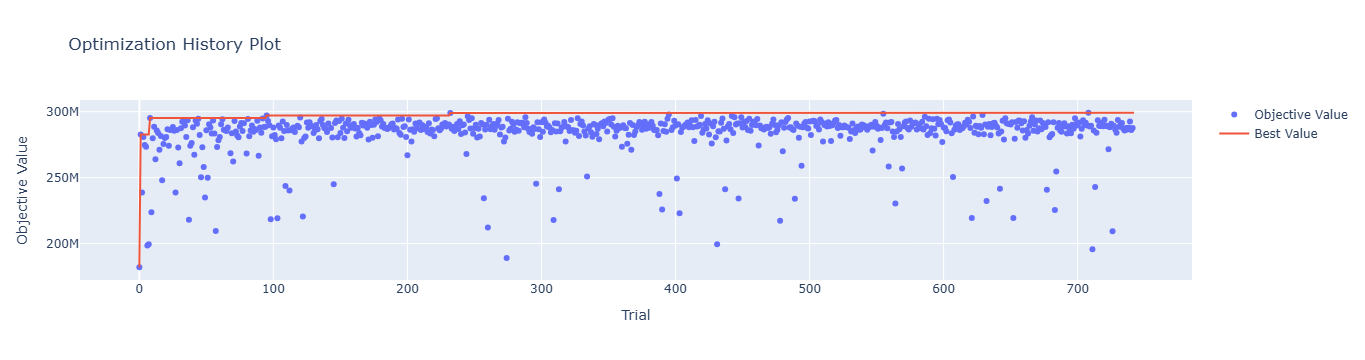

In [15]:
optuna.visualization.plot_optimization_history(study)

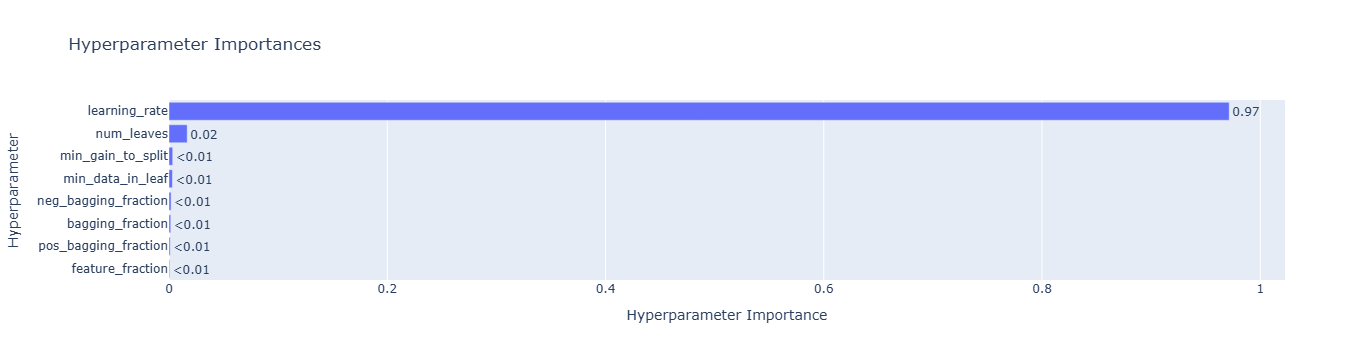

In [16]:
plot_param_importances(study)

# entrenamos

In [18]:
best_iter = study.best_trial.user_attrs["best_iter"]
print(f"Mejor cantidad de árboles para el mejor model {best_iter}")
params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'first_metric_only': True,
    'boost_from_average': True,
    'feature_pre_filter': False,
    'max_bin': 31,
    'num_leaves': study.best_trial.params['num_leaves'],
    'learning_rate': study.best_trial.params['learning_rate'],
    'min_data_in_leaf': study.best_trial.params['min_data_in_leaf'],
    'feature_fraction': study.best_trial.params['feature_fraction'],
    'bagging_fraction': study.best_trial.params['bagging_fraction'],
    'min_gain_to_split': study.best_trial.params['min_gain_to_split'],
    
    'pos_bagging_fraction': study.best_trial.params['pos_bagging_fraction'],
    'neg_bagging_fraction': study.best_trial.params['neg_bagging_fraction'],
    #'seed': SEMILLA,
    'verbose': 0
}




train_data = lgb.Dataset(X_train,
                          label=y_train_binaria2,
                          weight=w_train)

# model = lgb.train(params,
#                   train_data,
#                   num_boost_round=best_iter)



seeds = [123479, 123491, 123493, 123499, 123503, 123517, 123527, 123547, 123553, 123581]
predicciones = []

for seed in seeds:
    params['seed'] = seed
    print(f"\nEntrenando modelo con seed = {seed}")
    
    model = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=best_iter,
    )
    
    model.save_model(modelos_path + f'lgb_model_seed_{seed}.txt')
    
    # Predicciones para el mes de validación o test
    y_pred = model.predict(X_test)
    predicciones.append(y_pred)

# Promedio simple
y_pred_final = np.mean(predicciones, axis=0)

Mejor cantidad de árboles para el mejor model 403

Entrenando modelo con seed = 123479

Entrenando modelo con seed = 123491

Entrenando modelo con seed = 123493

Entrenando modelo con seed = 123499

Entrenando modelo con seed = 123503

Entrenando modelo con seed = 123517

Entrenando modelo con seed = 123527

Entrenando modelo con seed = 123547

Entrenando modelo con seed = 123553

Entrenando modelo con seed = 123581


In [20]:
# # load every model in modelos path to models
import os
models = []
for file in os.listdir(modelos_path):
    if file.endswith('.txt'):
        model = lgb.Booster(model_file=os.path.join(modelos_path, file))
        models.append(model)

In [26]:
models

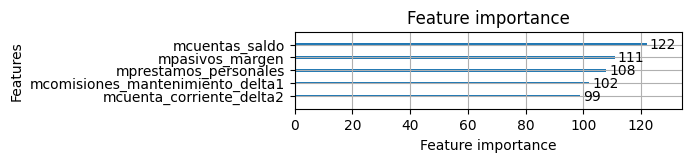

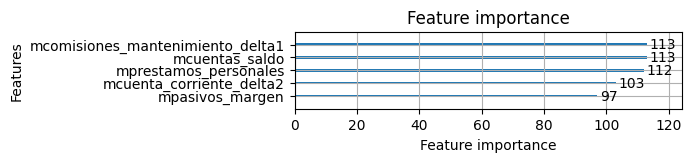

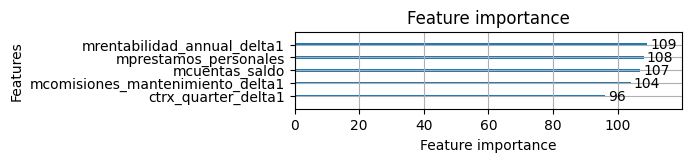

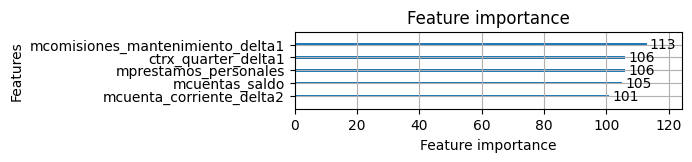

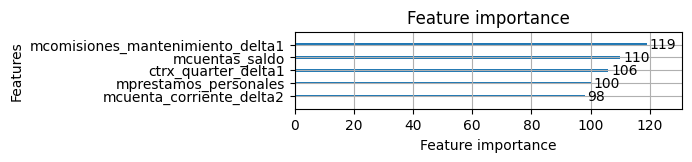

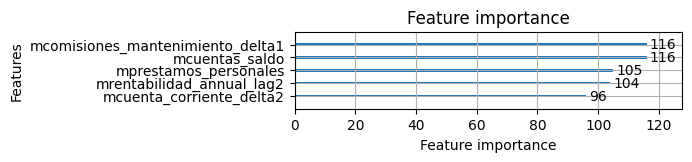

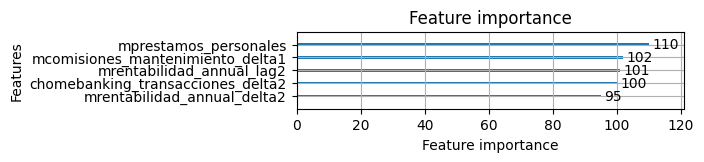

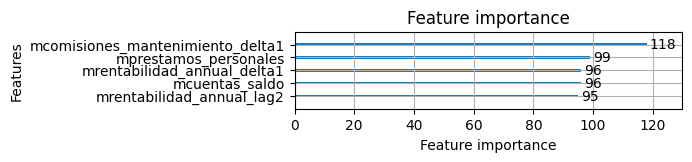

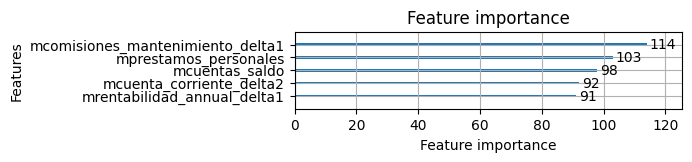

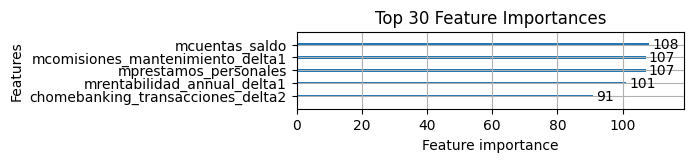

In [29]:
# compare top 30 feature importances of the first model and the second model
for i in range(10):
    lgb.plot_importance(models[i], max_num_features=5, figsize=(5, 1))
# lgb.plot_importance(models[7], max_num_features=5, figsize=(5, 1))
# lgb.plot_importance(models[8], max_num_features=5, figsize=(5, 1))
# lgb.plot_importance(models[9], max_num_features=5, figsize=(5, 1))
plt.title("Top 30 Feature Importances")
plt.show()

In [30]:
# save to y_pred every prediction in predictions list
y_pred_list = [pred for pred in predicciones]

In [32]:
def ganancia_prob(y_pred, y_true, prop = 1):
  ganancia = np.where(y_true == 1, ganancia_acierto, 0) - np.where(y_true == 0, costo_estimulo, 0)
  return ganancia[y_pred >= 0.03].sum() / prop

for i, y_pred in enumerate(y_pred_list):
    print(f"Ganancia LGBM seed {seeds[i]}:", ganancia_prob(y_pred, y_test_binaria1))

Ganancia LGBM seed 123479: 358420000.0
Ganancia LGBM seed 123491: 360840000.0
Ganancia LGBM seed 123493: 356460000.0
Ganancia LGBM seed 123499: 354240000.0
Ganancia LGBM seed 123503: 365220000.0
Ganancia LGBM seed 123517: 353960000.0
Ganancia LGBM seed 123527: 360020000.0
Ganancia LGBM seed 123547: 348880000.0
Ganancia LGBM seed 123553: 355940000.0
Ganancia LGBM seed 123581: 349860000.0


In [33]:
sss_futuro = StratifiedShuffleSplit(n_splits=50,
                             test_size=0.3,
                             random_state=SEMILLA)

# make models dictionary with the predictions of each model in y_pred_list
modelos = {}
for i, y_pred in enumerate(y_pred_list):
  modelos[f"lgbm_{i}"] = y_pred

# append to modelo y_pred_final
modelos["lgbm_final"] = y_pred_final

#modelos = {"lgbm":y_pred_list[0]}
rows = []
for private_index, public_index in sss_futuro.split(X_test, y_test_binaria1):
  row = {}
  for name, y_pred in modelos.items():
    row[name + "_public"] = ganancia_prob(y_pred[public_index], y_test_binaria1.iloc[public_index], 0.3)
    row[name + "_private"] = ganancia_prob(y_pred[private_index], y_test_binaria1.iloc[private_index], 0.7)
  rows.append(row)
df_lb = pd.DataFrame(rows)

In [34]:
df_lb_long = df_lb.reset_index().melt(id_vars='index',
                                      var_name='model_type',
                                      value_name='ganancia')

# split from the right: ["lgbm_0", "public"] / ["lgbm_0", "private"]
df_lb_long[['modelo', 'tipo']] = df_lb_long['model_type'].str.rsplit('_', n=1, expand=True)

df_lb_long = df_lb_long[['ganancia', 'tipo', 'modelo']]

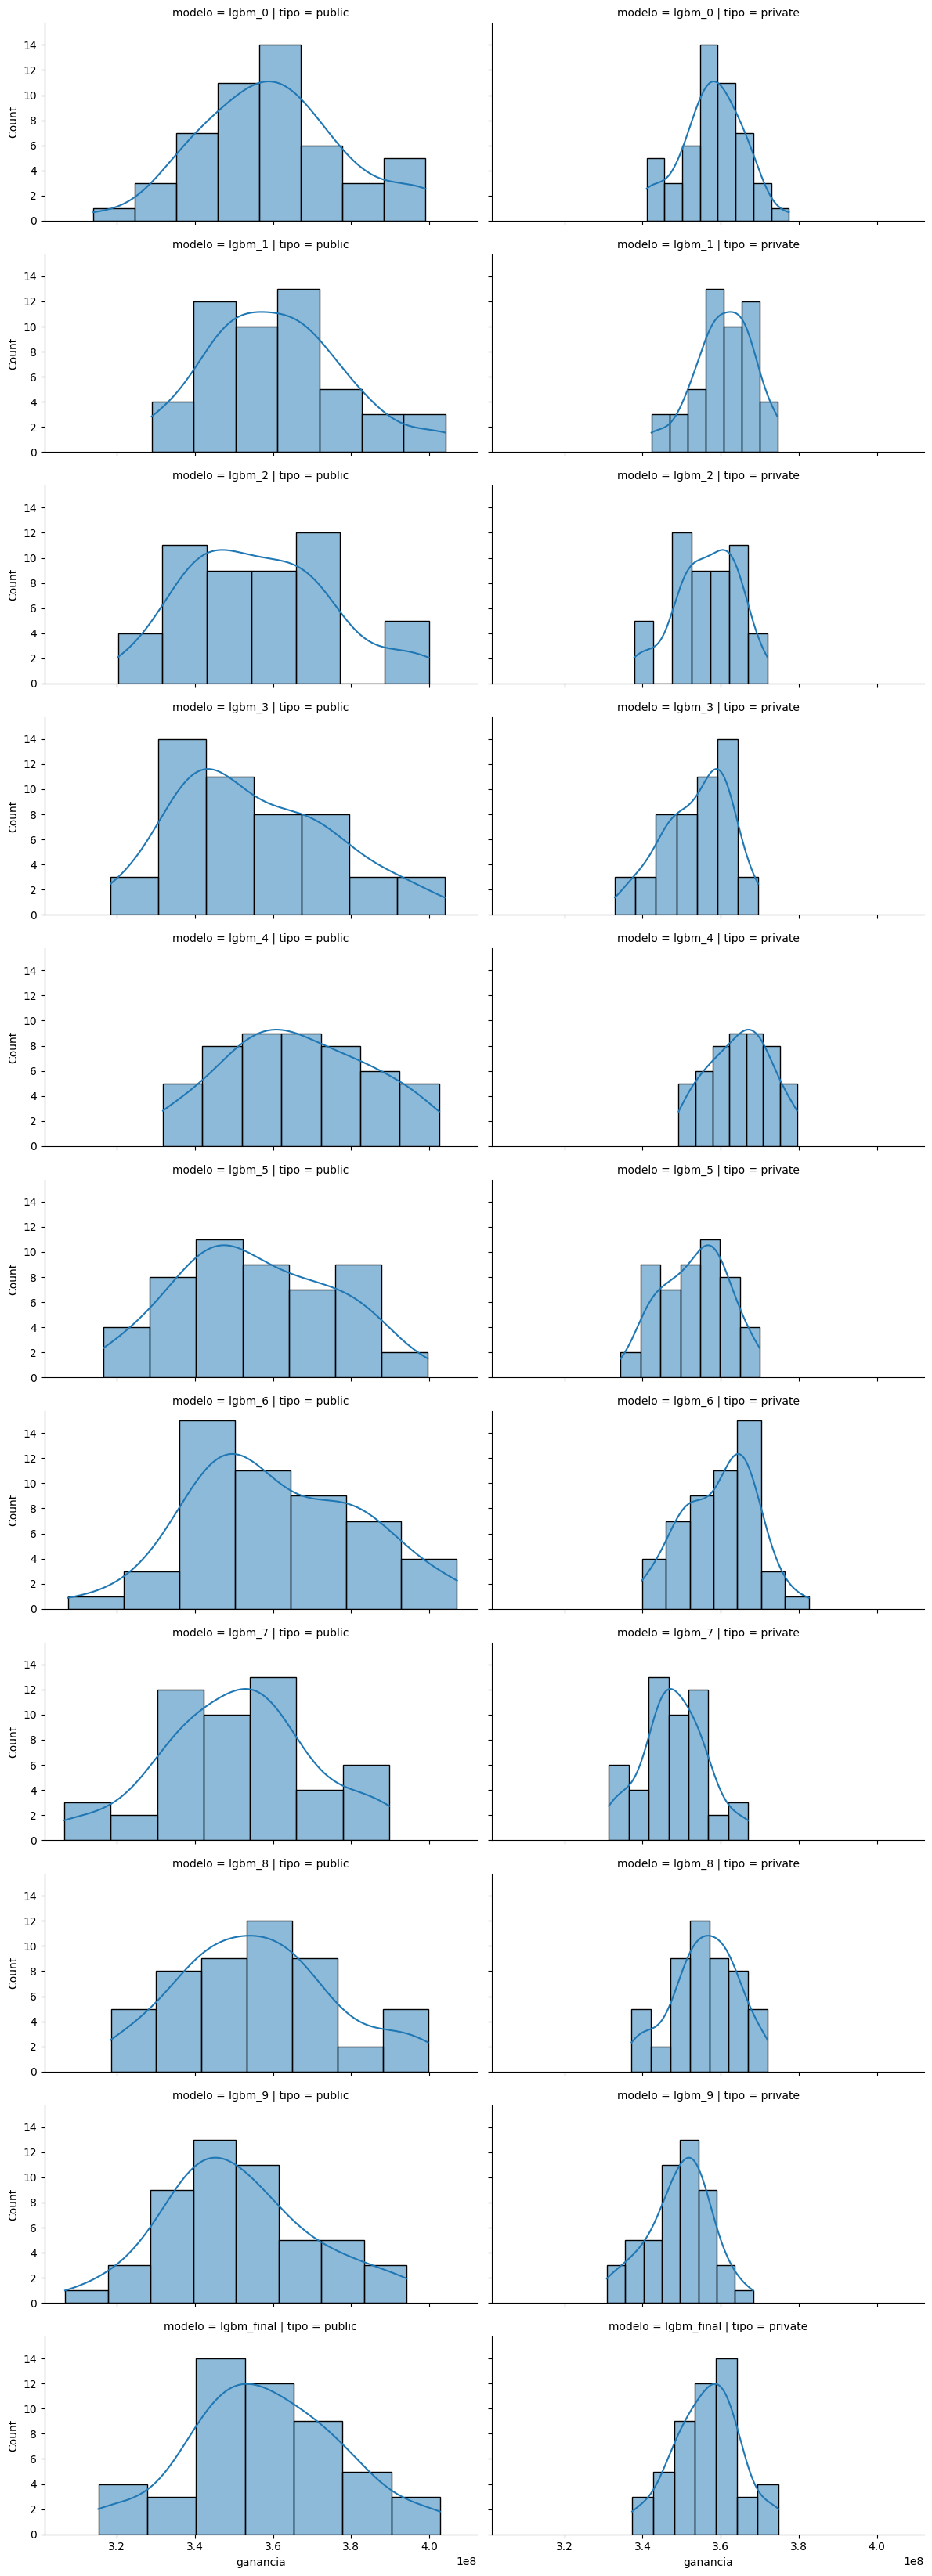

In [35]:
g = sns.FacetGrid(df_lb_long, col="tipo", row="modelo", aspect=2)
g.map(sns.histplot, "ganancia", kde=True)
plt.show()

In [36]:
ganancias_pred_list = []

for y_pred in y_pred_list:
    ganancia = np.where(y_test_binaria1 == 1, ganancia_acierto, 0) - np.where(y_test_binaria1 == 0, costo_estimulo, 0)
    idx = np.argsort(y_pred)[::-1]
    ganancia_sorted = ganancia[idx]
    y_pred_sorted = y_pred[idx]
    ganancia_cum = np.cumsum(ganancia_sorted)
    ganancias_pred_list.append({
        'y_pred_sorted': y_pred_sorted,
        'ganancia_sorted': ganancia_sorted,
        'ganancia_cum': ganancia_cum
    })

In [37]:
#calcular punto de corte a la ganancia maxima para cada item en ganancias_pred_list
puntos_corte = []
for item in ganancias_pred_list:
    ganancia_cum = item['ganancia_cum']
    max_ganancia = np.max(ganancia_cum)
    punto_corte = np.where(ganancia_cum == max_ganancia)[0][0]
    puntos_corte.append(punto_corte)
    print(f"Punto de corte: {punto_corte}, Ganancia máxima: {max_ganancia}")

Punto de corte: 9250, Ganancia máxima: 367780000
Punto de corte: 9389, Ganancia máxima: 367400000
Punto de corte: 8659, Ganancia máxima: 364400000
Punto de corte: 8951, Ganancia máxima: 364960000
Punto de corte: 9966, Ganancia máxima: 367860000
Punto de corte: 8931, Ganancia máxima: 361360000
Punto de corte: 9384, Ganancia máxima: 362700000
Punto de corte: 9776, Ganancia máxima: 358860000
Punto de corte: 8228, Ganancia máxima: 368220000
Punto de corte: 8158, Ganancia máxima: 368020000


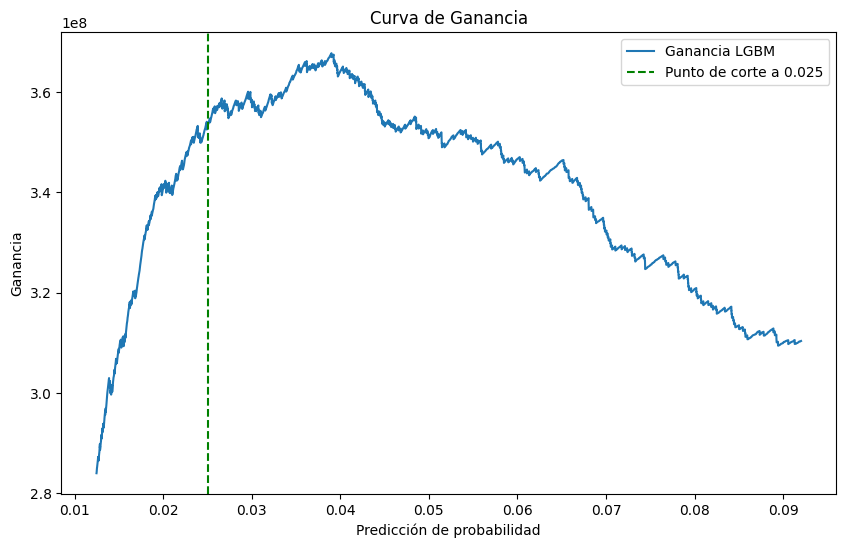

In [45]:
y_pred_lgm = y_pred_list[0]


ganancia = np.where(y_test_binaria1 == 1, ganancia_acierto, 0) - np.where(y_test_binaria1 == 0, costo_estimulo, 0)

idx = np.argsort(y_pred_lgm)[::-1]

ganancia = ganancia[idx]
y_pred_lgm = y_pred_lgm[idx]

ganancia_cum = np.cumsum(ganancia)

piso_envios = 4000
techo_envios = 20000

plt.figure(figsize=(10, 6))
plt.plot(y_pred_lgm[piso_envios:techo_envios], ganancia_cum[piso_envios:techo_envios], label='Ganancia LGBM')
plt.title('Curva de Ganancia')
plt.xlabel('Predicción de probabilidad')
plt.ylabel('Ganancia')
plt.axvline(x=0.025, color='g', linestyle='--', label='Punto de corte a 0.025')
plt.legend()
plt.show()

In [ ]:
# piso_envios = 4000
# techo_envios = 20000

# ganancia_max = ganancia_cum.max()
# gan_max_idx = np.where(ganancia_cum == ganancia_max)[0][0]

# plt.figure(figsize=(10, 6))
# plt.plot(range(piso_envios, len(ganancia_cum[piso_envios:techo_envios]) + piso_envios), ganancia_cum[piso_envios:techo_envios], label='Ganancia LGBM')
# plt.axvline(x=gan_max_idx, color='g', linestyle='--', label=f'Punto de corte a la ganancia máxima {gan_max_idx}')
# plt.axhline(y=ganancia_max, color='r', linestyle='--', label=f'Ganancia máxima {ganancia_max}')
# plt.title('Curva de Ganancia')
# plt.xlabel('Clientes')
# plt.ylabel('Ganancia')
# plt.legend()
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# def generate_kaggle_submission(model, data, foto_mes, n_envios, 
#                                output_path='submission.csv'):
#     """
#     Generate Kaggle submission file with top N clients by probability
    
#     Parameters:
#     -----------
#     model : trained model
#         Your trained LightGBM or other model
#     data : pd.DataFrame
#         Full dataset containing the foto_mes to predict
#     foto_mes : int
#         Month to predict (e.g., 202106)
#     n_envios : int
#         Number of clients to send stimulus to
#     output_path : str
#         Path to save the submission file
        
#     Returns:
#     --------
#     pd.DataFrame : submission dataframe
#     """
    
#     # Filter data for prediction month
#     X_pred = data[data['foto_mes'] == foto_mes].copy()
    
#     # Get number_cliente (the ID column)
#     numero_de_cliente = X_pred['numero_de_cliente'].copy()
    
#     # Drop non-feature columns
#     cols_to_drop = ['clase_ternaria', 'clase_peso', 'clase_binaria1','clase_binaria2', 'foto_mes', 'numero_de_cliente']
#     X_pred_features = X_pred.drop(columns=[col for col in cols_to_drop 
#                                             if col in X_pred.columns])
    
#     # Get predictions (probability of BAJA+2)
#     y_pred_proba = model.predict(X_pred_features)
    
#     # Create submission dataframe
#     submission = pd.DataFrame({
#         'numero_de_cliente': numero_de_cliente,
#         'Predicted': 0  # Default: no stimulus
#     })
    
#     # Sort by probability (descending) and select top N
#     submission['prob'] = y_pred_proba
#     submission = submission.sort_values('prob', ascending=False)
    
#     # Mark top N clients for stimulus
#     submission.iloc[:n_envios, submission.columns.get_loc('Predicted')] = 1
    
#     # Keep only required columns and sort by numero_de_cliente
#     submission = submission[['numero_de_cliente', 'Predicted']].sort_values('numero_de_cliente')
    
#     # Save to CSV
#     submission.to_csv(output_path, index=False)
    
#     print(f"✓ Submission file created: {output_path}")
#     print(f"✓ Total clients: {len(submission):,}")
#     print(f"✓ Clients with stimulus: {submission['Predicted'].sum():,}")
#     print(f"✓ Percentage: {100*submission['Predicted'].sum()/len(submission):.2f}%")
    
#     return submission


In [38]:
data.foto_mes.unique()

array([202101, 202102, 202103, 202104, 202105, 202106])

In [39]:
#data_final = data[data['foto_mes'].isin([202103, 202104, 202106])]

train_months = [202103, 202104]
predict_month = 202106

# Prepare training data (concatenate months 202103 and 202104)
train_df = data[data['foto_mes'].isin(train_months)].copy()

In [41]:
# Predict 202106 using the 5 seeds, average probabilities and save submission
# We will train a model for each seed using training months 202103 and 202104, predict for 202106,
# average the predicted probabilities and write a submission CSV.

X_train_all = train_df.drop(['clase_ternaria', 'clase_peso', 'clase_binaria1','clase_binaria2', 'foto_mes', 'numero_de_cliente'], axis=1)
y_train_all = train_df['clase_binaria2']  # estamos prediciendo BAJA+2 (clase_binaria2)
w_train_all = train_df['clase_peso']

# Data to predict (202106)
X_pred_df = data[data['foto_mes'] == predict_month].copy()
ids_pred = X_pred_df['numero_de_cliente'].copy()
X_pred_features = X_pred_df.drop(columns=[col for col in ['clase_ternaria', 'clase_peso', 'clase_binaria1','clase_binaria2', 'foto_mes', 'numero_de_cliente'] if col in X_pred_df.columns])


preds_list = []
for seed in seeds:
    print(f"Training with seed {seed} and predicting {predict_month}...")
    params_local = params.copy()
    params_local['seed'] = seed

    train_set = lgb.Dataset(X_train_all, label=y_train_all, weight=w_train_all)
    # Use best_iter from study if available, otherwise use a reasonable default (100)
    n_rounds = best_iter

    model_tmp = lgb.train(params_local, train_set, num_boost_round=n_rounds)
    # predict probabilities for BAJA+2
    y_pred_tmp = model_tmp.predict(X_pred_features)
    preds_list.append(y_pred_tmp)


Training with seed 123479 and predicting 202106...
Training with seed 123491 and predicting 202106...
Training with seed 123493 and predicting 202106...
Training with seed 123499 and predicting 202106...
Training with seed 123503 and predicting 202106...
Training with seed 123517 and predicting 202106...
Training with seed 123527 and predicting 202106...
Training with seed 123547 and predicting 202106...
Training with seed 123553 and predicting 202106...
Training with seed 123581 and predicting 202106...


In [44]:
# Average probabilities across the seeds
preds_avg = np.mean(preds_list, axis=0)

# Build submission dataframe: mark top N by average probability where N = average puntos_corte (as used earlier)
n_envios = int(np.max(puntos_corte))
submission_avg = pd.DataFrame({'numero_de_cliente': ids_pred, 'prob': preds_avg})
submission_avg = submission_avg.sort_values('prob', ascending=False).reset_index(drop=True)
submission_avg['Predicted'] = 0

submission_avg.loc[submission_avg.index[:n_envios], 'Predicted'] = 1
#submission_avg.loc[:n_envios-1, 'Predicted'] = 1

# final ordered by numero_de_cliente as required by the competition
submission_to_save = submission_avg[['numero_de_cliente', 'Predicted']].sort_values('numero_de_cliente')
submission_to_save.to_csv('exp_601_submission_mix_seeds_avg_best_hp_10_seeds_max_cutoff.csv', index=False)
print(f"✓ Saved averaged submission to exp_601_submission_mix_seeds_202106.csv. Total clients: {len(submission_to_save):,}, Stimulated: {submission_to_save['Predicted'].sum():,}")

✓ Saved averaged submission to exp_601_submission_mix_seeds_202106.csv. Total clients: 164,313, Stimulated: 9,966
